# Synchronous Magnitudes model -- 1-side run

Back-end: `structure_FNs_magnitudes_2026`. Reward structure is data-driven (`make_linear_pairs`), the test phase reports per-pair statistics, and there is a full all-pairs sweep for measuring symbolic-distance and serial-position effects.

In [1]:
import random
import numpy as np
import time
import numba
import math
from numpy.random import Generator, PCG64DXSM, SeedSequence
import multiprocessing as mp
mp.set_start_method('spawn', force=True)
from structure_FNs_magnitudes_2026 import play_sequence

np.set_printoptions(suppress=True)

In [2]:
# ---- pair / reward construction (no hard-coding of sequence length) ----
def make_linear_pairs(n):
    """Linear transitive-inference pair sets for stimuli 0..n-1, listed as
    (forward, reverse) in i<j order (matches the original 5-stimulus arrays).
      pairs       : adjacent ordered pairs (distance 1)
      nonadjpairs : non-adjacent pairs touching an extreme (0 or n-1) [trained]
      testpairs   : interior non-adjacent pairs (touch neither extreme) [held out]
    Reward rule: the larger stimulus index is the rewarded position.
    Swap this helper out (or edit the *_reward arrays) for circular,
    reverse-on-nonadjacent, rock-paper-scissors, etc.
    """
    ext = {0, n - 1}
    pairs, nonadj, test = [], [], []
    for i in range(n):
        for j in range(i + 1, n):
            d = j - i
            fwd, rev = [i, j], [j, i]
            if d == 1:
                pairs += [fwd, rev]
            elif (i in ext) or (j in ext):
                nonadj += [fwd, rev]
            else:
                test += [fwd, rev]
    def rew(arr):
        if len(arr) == 0:
            return np.zeros((0, 2), dtype=np.int64)
        return np.asarray([[1, 0] if a > b else [0, 1] for a, b in arr], dtype=np.int64)
    pairs = np.asarray(pairs, dtype=np.int64)
    nonadj = np.asarray(nonadj, dtype=np.int64) if nonadj else np.zeros((0, 2), dtype=np.int64)
    test = np.asarray(test, dtype=np.int64) if test else np.zeros((0, 2), dtype=np.int64)
    return pairs, nonadj, test, rew(pairs), rew(nonadj), rew(test)


# ---- experiment parameters ----
terms = 7                         # sequence length; set to 5, 7, 9, ... freely
sides = 1                         # 1 = one stimulus set (adjacent-only); 2 = two sets

pairs, nonadjpairs, testpairs, pairs_reward, nonadjpairs_reward, testpairs_reward = \
    make_linear_pairs(terms)
allpairs        = np.concatenate((pairs, nonadjpairs, testpairs))
allpairs_reward = np.concatenate((pairs_reward, nonadjpairs_reward, testpairs_reward))

plen = len(pairs)
alen = len(allpairs)

maxvalue = 10
startstop = 2
noise = 0.
annealing = 0.

timesteps = 10**8                 # training plays per run (long; reduce to test)
runs = 100

rein1 = 4
rein2 = 4
punish1 = -11
punish2 = -11
inertia = 1

nsteps = 500
blocklength = nsteps*1

evalperpair = 2000                # read-only test plays sampled per pair, per run

print('terms =', terms, ' sides =', sides)
print('#adjacent =', plen, ' #all =', alen, ' #testpairs =', len(testpairs))
print('test pairs:', testpairs.tolist())
print('test distances:', np.abs(testpairs[:,0]-testpairs[:,1]).tolist())

terms = 7  sides = 1
#adjacent = 12  #all = 42  #testpairs = 12
test pairs: [[1, 3], [3, 1], [1, 4], [4, 1], [1, 5], [5, 1], [2, 4], [4, 2], [2, 5], [5, 2], [3, 5], [5, 3]]
test distances: [2, 2, 3, 3, 4, 4, 2, 2, 3, 3, 2, 2]


In [3]:
# ---- distance / serial-position analysis helpers ----
def pair_distance(pairs_arr, terms, circular=False):
    """Symbolic distance of each ordered pair. Set circular=True to use the
    shorter way around a ring (min(d, terms-d))."""
    d = np.abs(pairs_arr[:, 0].astype(int) - pairs_arr[:, 1].astype(int))
    if circular:
        d = np.minimum(d, terms - d)
    return d

def per_run_rate(pair_stats, cols):
    """Per-run accuracy pooled over the given pair columns (nan if no attempts)."""
    att = pair_stats[:, cols, 0].sum(axis=1).astype(float)
    suc = pair_stats[:, cols, 1].sum(axis=1).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(att > 0, suc / att, np.nan)

def distance_table(pairs_arr, pair_stats, terms, circular=False, title=''):
    """Print mean accuracy grouped by symbolic distance, with SE across runs.
    A rising mean_acc with distance is the symbolic distance effect."""
    d = pair_distance(pairs_arr, terms, circular)
    if title:
        print(title)
    print(f"{'distance':>8} | {'n_pairs':>7} | {'mean_acc':>8} | {'SE':>7} | {'n_runs':>6}")
    print('-' * 50)
    for dist in np.unique(d):
        cols = np.where(d == dist)[0]
        run_acc = per_run_rate(pair_stats, cols)
        valid = run_acc[~np.isnan(run_acc)]
        m = valid.mean() if len(valid) else float('nan')
        se = valid.std(ddof=1) / np.sqrt(len(valid)) if len(valid) > 1 else float('nan')
        print(f'{int(dist):>8} | {len(cols):>7} | {m:>8.4f} | {se:>7.4f} | {len(valid):>6}')
    print(' ')

def per_pair_table(pairs_arr, pair_stats, terms, circular=False, title=''):
    """Print mean accuracy for every individual pair (sorted by distance, then
    by pair). Differences among pairs at the same distance reveal serial
    position effects."""
    d = pair_distance(pairs_arr, terms, circular)
    with np.errstate(invalid='ignore', divide='ignore'):
        rates = np.where(pair_stats[:, :, 0] > 0,
                         pair_stats[:, :, 1] / pair_stats[:, :, 0], np.nan)
    mean_acc = np.nanmean(rates, axis=0)
    n_valid = np.sum(~np.isnan(rates), axis=0)
    order = np.lexsort((np.arange(len(pairs_arr)), d))
    if title:
        print(title)
    print(f"{'pair':>10} | {'dist':>4} | {'mean_acc':>8} | {'n_runs':>6}")
    print('-' * 38)
    for i in order:
        pr = f'{int(pairs_arr[i,0])}-{int(pairs_arr[i,1])}'
        print(f'{pr:>10} | {int(d[i]):>4} | {mean_acc[i]:>8.4f} | {int(n_valid[i]):>6}')
    print(' ')

In [4]:
# use this cell for running the code
import concurrent.futures
start = time.perf_counter()
intermediate_start = time.perf_counter()

for rein1 in range(1, 6):
    rein2 = rein1
    for punish1 in range(0, -12, -2):
        punish2 = punish1

        sq1 = SeedSequence()
        randomentropy = sq1.entropy
        print('*************************************************************')
        print(randomentropy)
        sg = SeedSequence(randomentropy)
        rgs = [Generator(PCG64DXSM(s)) for s in sg.spawn(runs)]

        final_sigweights      = [None] * runs
        final_cumsuc          = [None] * runs
        final_cumsucadd       = [None] * runs
        final_testcumsucadd   = [None] * runs
        final_recweights      = [None] * runs
        final_test_pair_stats = [None] * runs
        final_all_pair_stats  = [None] * runs

        with concurrent.futures.ProcessPoolExecutor(max_workers=25) as executor:
            future_to_run = {executor.submit(play_sequence,
                n, rgs[n], rein1, punish1, rein2, punish2, timesteps, nsteps, sides,
                pairs, testpairs, nonadjpairs, allpairs,
                pairs_reward, testpairs_reward, nonadjpairs_reward, allpairs_reward,
                plen, alen, terms, maxvalue, startstop, noise, annealing, runs,
                inertia, blocklength, evalperpair): n for n in range(runs)}
            for future in concurrent.futures.as_completed(future_to_run):
                n = future_to_run[future]
                try:
                    (sigweights, cumsuc, cumsucadd, testcumsucadd,
                    recweights, test_pair_stats, all_pair_stats) = future.result()
                except Exception as exc:
                    print(f'run {n} generated an exception: {exc}')
                else:
                    final_sigweights[n]      = sigweights
                    final_cumsuc[n]          = cumsuc
                    final_cumsucadd[n]       = cumsucadd
                    final_testcumsucadd[n]   = testcumsucadd
                    final_recweights[n]      = recweights
                    final_test_pair_stats[n] = test_pair_stats
                    final_all_pair_stats[n]  = all_pair_stats
                    if n % 100 == 0:
                        print(f'finished run #{n}')

        final_sigweights      = np.asarray(final_sigweights)
        final_cumsuc          = np.asarray(final_cumsuc)
        final_cumsucadd       = np.asarray(final_cumsucadd)
        final_testcumsucadd   = np.asarray(final_testcumsucadd)
        final_recweights      = np.asarray(final_recweights)
        final_test_pair_stats = np.asarray(final_test_pair_stats)   # (runs, n_testpairs, 2)
        final_all_pair_stats  = np.asarray(final_all_pair_stats)    # (runs, n_allpairs, 2)

        
        print(f'for reinforcement {rein1} and punishment {punish1}')
        print('average cumsuc =')
        print(np.average(final_cumsuc)/runs)
        print(' ')
        print('average final-block training rate =')
        print(np.average(final_cumsucadd)/nsteps)
        print(' ')
        # overall held-out test rate, pooled from the per-pair stats (normalization-free)
        test_att = final_test_pair_stats[:, :, 0].sum()
        test_suc = final_test_pair_stats[:, :, 1].sum()
        print('overall test rate (held-out pairs) =')
        print(test_suc / test_att)
        print(' ')
        distance_table(testpairs, final_test_pair_stats, terms, circular=False,
                    title='Symbolic distance effect -- held-out test pairs')
        intermediate_finish = time.perf_counter()
        print(f'This parameter block finished in {round(intermediate_finish-intermediate_start,0)/60} minutes')
        intermediate_start = time.perf_counter()
        print('*************************************************************')
        print(' ')
        print(' ')


finish = time.perf_counter()
print(f'Finished in {round(finish-start,0)/60} minutes')

*************************************************************
206916865085553689344139151038615730822
finished run #0
for reinforcement 1 and punishment 0
average cumsuc =
790941.457
 
average final-block training rate =
0.81226
 
overall test rate (held-out pairs) =
0.46778
 
Symbolic distance effect -- held-out test pairs
distance | n_pairs | mean_acc |      SE | n_runs
--------------------------------------------------
       2 |       6 |   0.4970 |  0.0140 |    100
       3 |       4 |   0.4005 |  0.0215 |    100
       4 |       2 |   0.5134 |  0.0194 |    100
 
This parameter block finished in 14.216666666666667 minutes
*************************************************************
 
 
*************************************************************
20444037082006493135677752201577123146
finished run #0
for reinforcement 1 and punishment -2
average cumsuc =
996772.8152
 
average final-block training rate =
0.99836
 
overall test rate (held-out pairs) =
0.5781791666666667
 
Symbolic 

In [4]:
# np.save('magnitudes_1s_MV10_sigweights', final_sigweights)
# np.save('magnitudes_1s_MV10_recweights', final_recweights)
# np.save('magnitudes_1s_MV10_testcumsucadd', final_testcumsucadd)
# np.save('magnitudes_1s_MV10_test_pair_stats', final_test_pair_stats)
# np.save('magnitudes_1s_MV10_all_pair_stats', final_all_pair_stats)
# # save the pair arrays too, so distances can be recomputed later
# np.save('magnitudes_1s_MV10_testpairs', testpairs)
# np.save('magnitudes_1s_MV10_allpairs', allpairs)

## Distance / serial-position analysis

In [4]:
# ---- distance / serial-position analysis helpers ----
def pair_distance(pairs_arr, terms, circular=False):
    """Symbolic distance of each ordered pair. Set circular=True to use the
    shorter way around a ring (min(d, terms-d))."""
    d = np.abs(pairs_arr[:, 0].astype(int) - pairs_arr[:, 1].astype(int))
    if circular:
        d = np.minimum(d, terms - d)
    return d

def per_run_rate(pair_stats, cols):
    """Per-run accuracy pooled over the given pair columns (nan if no attempts)."""
    att = pair_stats[:, cols, 0].sum(axis=1).astype(float)
    suc = pair_stats[:, cols, 1].sum(axis=1).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(att > 0, suc / att, np.nan)

def distance_table(pairs_arr, pair_stats, terms, circular=False, title=''):
    """Print mean accuracy grouped by symbolic distance, with SE across runs.
    A rising mean_acc with distance is the symbolic distance effect."""
    d = pair_distance(pairs_arr, terms, circular)
    if title:
        print(title)
    print(f"{'distance':>8} | {'n_pairs':>7} | {'mean_acc':>8} | {'SE':>7} | {'n_runs':>6}")
    print('-' * 50)
    for dist in np.unique(d):
        cols = np.where(d == dist)[0]
        run_acc = per_run_rate(pair_stats, cols)
        valid = run_acc[~np.isnan(run_acc)]
        m = valid.mean() if len(valid) else float('nan')
        se = valid.std(ddof=1) / np.sqrt(len(valid)) if len(valid) > 1 else float('nan')
        print(f'{int(dist):>8} | {len(cols):>7} | {m:>8.4f} | {se:>7.4f} | {len(valid):>6}')
    print(' ')

def per_pair_table(pairs_arr, pair_stats, terms, circular=False, title=''):
    """Print mean accuracy for every individual pair (sorted by distance, then
    by pair). Differences among pairs at the same distance reveal serial
    position effects."""
    d = pair_distance(pairs_arr, terms, circular)
    with np.errstate(invalid='ignore', divide='ignore'):
        rates = np.where(pair_stats[:, :, 0] > 0,
                         pair_stats[:, :, 1] / pair_stats[:, :, 0], np.nan)
    mean_acc = np.nanmean(rates, axis=0)
    n_valid = np.sum(~np.isnan(rates), axis=0)
    order = np.lexsort((np.arange(len(pairs_arr)), d))
    if title:
        print(title)
    print(f"{'pair':>10} | {'dist':>4} | {'mean_acc':>8} | {'n_runs':>6}")
    print('-' * 38)
    for i in order:
        pr = f'{int(pairs_arr[i,0])}-{int(pairs_arr[i,1])}'
        print(f'{pr:>10} | {int(d[i]):>4} | {mean_acc[i]:>8.4f} | {int(n_valid[i]):>6}')
    print(' ')

In [5]:
# ---- distance effect on the HELD-OUT test pairs ----
# (set circular=True if you trained a circular ordering)
distance_table(testpairs, final_test_pair_stats, terms, circular=False,
               title='Symbolic distance effect -- held-out test pairs')

# ---- distance effect across ALL pairs (full spectrum, incl. distance 1) ----
distance_table(allpairs, final_all_pair_stats, terms, circular=False,
               title='Symbolic distance effect -- all pairs')

# ---- per-pair breakdown across all pairs (for serial position effects) ----
per_pair_table(allpairs, final_all_pair_stats, terms, circular=False,
               title='Per-pair accuracy -- all pairs (serial position)')

Symbolic distance effect -- held-out test pairs
distance | n_pairs | mean_acc |      SE | n_runs
--------------------------------------------------
       2 |       6 |   0.5909 |  0.0062 |   1000
       3 |       4 |   0.4073 |  0.0105 |   1000
       4 |       2 |   0.7189 |  0.0085 |   1000
 
Symbolic distance effect -- all pairs
distance | n_pairs | mean_acc |      SE | n_runs
--------------------------------------------------
       1 |      12 |   0.9997 |  0.0000 |   1000
       2 |      10 |   0.6299 |  0.0053 |   1000
       3 |       8 |   0.4171 |  0.0093 |   1000
       4 |       6 |   0.7144 |  0.0072 |   1000
       5 |       4 |   0.8668 |  0.0065 |   1000
       6 |       2 |   0.7309 |  0.0092 |   1000
 
Per-pair accuracy -- all pairs (serial position)
      pair | dist | mean_acc | n_runs
--------------------------------------
       0-1 |    1 |   0.9998 |   1000
       1-0 |    1 |   0.9998 |   1000
       1-2 |    1 |   0.9996 |   1000
       2-1 |    1 |   0.9996 

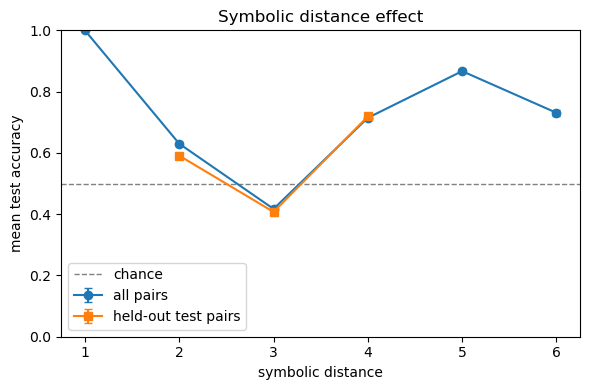

In [8]:
# ---- plot mean accuracy as a function of symbolic distance ----
import matplotlib.pyplot as plt

def distance_means(pairs_arr, pair_stats, terms, circular=False):
    """For each symbolic distance present in pairs_arr, return three arrays:
        xs  -- the distance value
        ms  -- mean accuracy across runs (pooled over pairs at that distance)
        ses -- standard error of that mean: sample SD / sqrt(n_runs)
    """
    d = pair_distance(pairs_arr, terms, circular)
    xs, ms, ses = [], [], []
    for dist in np.unique(d):
        cols = np.where(d == dist)[0]
        run_acc = per_run_rate(pair_stats, cols)            # one accuracy per run
        xs.append(int(dist))
        ms.append(run_acc.mean())
        ses.append(run_acc.std(ddof=1) / np.sqrt(len(run_acc)))
    return np.array(xs), np.array(ms), np.array(ses)

xt, mt, st = distance_means(testpairs, final_test_pair_stats, terms)
xa, ma, sa = distance_means(allpairs,  final_all_pair_stats,  terms)

# Open a new figure 6 inches wide, 4 tall
plt.figure(figsize=(6, 4))

# Plot mean accuracy (ma, mt) versus distance (xa, xt) with vertical SEM bars.
#   yerr    : half-height of the error bar (one SEM up, one SEM down)
#   marker  : shape of each point  ('o' = circle, 's' = square)
#   capsize : width of the little horizontal cap at each end of the bar
plt.errorbar(xa, ma, yerr=sa, marker='o', capsize=3, label='all pairs')
plt.errorbar(xt, mt, yerr=st, marker='s', capsize=3, label='held-out test pairs')

# Dashed grey horizontal reference line at the chance level (50%)
plt.axhline(0.5, ls='--', lw=1, color='grey', label='chance')

# Axis labels, title, y-range (accuracy lives in [0, 1]), legend
plt.xlabel('symbolic distance')
plt.ylabel('mean test accuracy')
plt.title('Symbolic distance effect')
plt.xticks(xa)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()   # auto-adjust margins so nothing gets clipped
plt.show()

## Duplicate-bin diagnostic

In [7]:
# how many runs converged to sender strategies in which the same magnitude
# pair (receiver urn) encodes two distinct stimulus pairings (cf. paper fn. 6-7).
# For the magnitudes model the modal transmitted magnitude for a stimulus is the
# number of urns whose 1-ball outweighs its 0-ball.
@numba.njit
def duplicates(dbins):
    dup = 0
    for iii in range(len(dbins)):
        for jjj in range(len(dbins)):
            if iii != jjj:
                if (dbins[iii][0] == dbins[jjj][0]) & (dbins[iii][1] == dbins[jjj][1]):
                    dup = 1
    return dup

@numba.njit
def runs_dup_bins(runs, fsigweights, t, maxvalue):
    dup_count = 0
    for i0 in range(runs):
        sw = fsigweights[i0]
        swl = np.zeros(t, dtype=numba.int64)
        swr = np.zeros(t, dtype=numba.int64)
        for s in range(t):
            cl = 0
            cr = 0
            for u in range(maxvalue):
                if sw[0, 0, s, u, 1] > sw[0, 0, s, u, 0]:
                    cl += 1
                if sw[0, 1, s, u, 1] > sw[0, 1, s, u, 0]:
                    cr += 1
            swl[s] = cl
            swr[s] = cr
        bns = np.zeros(((2*(t-1)), 2), dtype=numba.int64)
        for idx000 in range(t-1):
            bns[idx000][0] = swl[idx000]
            bns[idx000][1] = swr[idx000+1]
        for idx001 in range(t-1):
            bns[t-1+idx001][0] = swl[idx001+1]
            bns[t-1+idx001][1] = swr[idx001]
        dup_count += duplicates(bns)
    return dup_count

print('runs with duplicate bins:', runs_dup_bins(runs, final_sigweights, terms, maxvalue))

runs with duplicate bins: 684
